# Data Description
These datasets are meteorological data from the HI-SEAS weather station from four months (September through December 2016) between Mission IV and Mission V.

For each dataset, the fields are:

A row number (1-n) useful in sorting this export's results The UNIX time_t date (seconds since Jan 1, 1970). Useful in sorting this export's results with other export's results The date in yyyy-mm-dd format The local time of day in hh:mm:ss 24-hour format The numeric data, if any (may be an empty string) The text data, if any (may be an empty string)

The units of each dataset are:  

Solar radiation: watts per meter^2  
Temperature: degrees Fahrenheit  
Humidity: percent  
Barometric pressure: Hg  
Wind direction: degrees  
Wind speed: miles per hour  
Sunrise/sunset: Hawaii time  
link: https://www.kaggle.com/datasets/dronio/SolarEnergy


# Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import re

from sklearn.preprocessing import StandardScaler,MinMaxScaler

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.feature_selection import SelectKBest,f_regression
from sklearn.inspection import permutation_importance

from sklearn.model_selection import train_test_split
import xgboost as xgb
from xgboost import XGBRegressor

from tensorflow.keras.layers import Dense,Dropout,Activation # type: ignore
from tensorflow.keras.optimizers import SGD,Adam # type: ignore
from tensorflow.keras.models import Sequential # type: ignore

from sklearn.metrics import mean_squared_error, median_absolute_error, r2_score
import joblib


In [2]:
import warnings
warnings.filterwarnings('ignore')

### Loading Data

In [3]:
data=pd.read_csv('SolarPrediction.csv')

In [4]:
data

,UNIXTime,Data,Time,Radiation,Temperature,Pressure,Humidity,WindDirection(Degrees),Speed,TimeSunRise,TimeSunSet
0,1475229326,9/29/2016 12:00:00 AM,23:55:26,1.21,48,30.46,59,177.39,5.62,06:13:00,18:13:00
1,1475229023,9/29/2016 12:00:00 AM,23:50:23,1.21,48,30.46,58,176.78,3.37,06:13:00,18:13:00
2,1475228726,9/29/2016 12:00:00 AM,23:45:26,1.23,48,30.46,57,158.75,3.37,06:13:00,18:13:00
3,1475228421,9/29/2016 12:00:00 AM,23:40:21,1.21,48,30.46,60,137.71,3.37,06:13:00,18:13:00
4,1475228124,9/29/2016 12:00:00 AM,23:35:24,1.17,48,30.46,62,104.95,5.62,06:13:00,18:13:00
...,...,...,...,...,...,...,...,...,...,...,...
32681,1480587604,12/1/2016 12:00:00 AM,00:20:04,1.22,44,30.43,102,145.42,6.75,06:41:00,17:42:00
32682,1480587301,12/1/2016 12:00:00 AM,00:15:01,1.17,44,30.42,102,117.78,6.75,06:41:00,17:42:00
32683,1480587001,12/1/2016 12:00:00 AM,00:10:01,1.20,44,30.42,102,145.19,9.00,06:41:00,17:42:00
32684,1480586702,12/1/2016 12:00:00 AM,00:05:02,1.23,44,30.42,101,164.19,7.87,06:41:00,17:42:00


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32686 entries, 0 to 32685
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   UNIXTime                32686 non-null  int64  
 1   Data                    32686 non-null  object 
 2   Time                    32686 non-null  object 
 3   Radiation               32686 non-null  float64
 4   Temperature             32686 non-null  int64  
 5   Pressure                32686 non-null  float64
 6   Humidity                32686 non-null  int64  
 7   WindDirection(Degrees)  32686 non-null  float64
 8   Speed                   32686 non-null  float64
 9   TimeSunRise             32686 non-null  object 
 10  TimeSunSet              32686 non-null  object 
dtypes: float64(4), int64(3), object(4)
memory usage: 2.7+ MB


# Data Wrangling

In [6]:
df=data.copy()

In [7]:
df['Data']=df['Data'].apply(lambda x: x.split()[0])

In [8]:
df['Month']=pd.to_datetime(df['Data']).dt.month

In [9]:
df['Day']=pd.to_datetime(df['Data']).dt.day

df['Hour']=pd.to_datetime(df['Time']).dt.hour
df['Minute']=pd.to_datetime(df['Time']).dt.minute
df['Second']=pd.to_datetime(df['Time']).dt.second

In [10]:
# '^\d' means that I don't want any digit ('^' this symbol means 'not')
df['risehour'] = df['TimeSunRise'].apply(lambda x : re.search(r'^\d+', x).group(0)).astype(int)
df['riseminuter'] = df['TimeSunRise'].apply(lambda x : re.search(r'(?<=\:)\d+(?=\:)', x).group(0)).astype(int)

df['sethour'] = df['TimeSunSet'].apply(lambda x : re.search(r'^\d+', x).group(0)).astype(int)
df['setminute'] = df['TimeSunSet'].apply(lambda x : re.search(r'(?<=\:)\d+(?=\:)', x).group(0)).astype(int)

In [11]:
df.drop(['UNIXTime','Data','Time','TimeSunRise','TimeSunSet'],axis=1,inplace=True)

In [12]:
input_features=df.drop(['Radiation'],axis=1)
target=df['Radiation']

# Outlier Removal Across All Selected Features

This cell removes physically impossible rows and then drops IQR outliers using all input features, not just the Radiation target.

In [13]:
# Remove extreme physically impossible values and IQR outliers from all selected features
selected_features = input_features.columns.tolist()

physical_limits = {
    "Radiation": (0, 1200),
    "Temperature": (-50, 140),
    "Humidity": (0, 100),
    "Pressure": (25, 31.5),
    "WindDirection(Degrees)": (0, 360),
    "risehour": (0, 23),
    "riseminuter": (0, 59),
    "sethour": (0, 23),
}

df_clean = df.copy()
physical_mask = pd.Series(True, index=df_clean.index)
for feature, (low, high) in physical_limits.items():
    if feature in df_clean.columns:
        physical_mask &= df_clean[feature].between(low, high)

physical_rows_removed = (~physical_mask).sum()
df_clean = df_clean[physical_mask].copy()

# Exclude Speed from the multi-feature IQR filter so high-wind rows are not removed unfairly.
iqr_features = [f for f in selected_features if f != 'Speed']
Q1 = df_clean[iqr_features].quantile(0.25)
Q3 = df_clean[iqr_features].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_mask = ((df_clean[iqr_features] >= lower_bound) & (df_clean[iqr_features] <= upper_bound)).all(axis=1)
iqr_rows_removed = (~iqr_mask).sum()
df_clean = df_clean[iqr_mask].copy()

print(f"Original row count: {df.shape[0]}")
print(f"Removed physically impossible rows: {physical_rows_removed}")
print(f"Removed IQR outlier rows across selected features (excluding Speed): {iqr_rows_removed}")
print(f"Remaining rows after cleaning: {df_clean.shape[0]}")

df = df_clean
input_features = df.drop(["Radiation"], axis=1)

target = df["Radiation"]

Original row count: 32686
Removed physically impossible rows: 4360
Removed IQR outlier rows across selected features (excluding Speed): 4394
Remaining rows after cleaning: 23932


### Feature Selection using correlation matrix


In [14]:
corr_matrix=df.corr()
corr_matrix

,Radiation,Temperature,Pressure,Humidity,WindDirection(Degrees),Speed,Month,Day,Hour,Minute,Second,risehour,riseminuter,sethour,setminute
Radiation,1.000000,0.751680,0.117054,-0.190741,-0.471945,0.059233,-0.084953,0.057760,0.013104,-0.000641,-0.015809,NaN,-0.083914,0.029984,-0.024572
Temperature,0.751680,1.000000,0.258314,-0.283325,-0.494073,-0.051731,-0.318706,-0.068632,0.192867,-0.002765,-0.004443,NaN,-0.348910,0.254487,-0.194456
Pressure,0.117054,0.258314,1.000000,-0.291544,-0.117368,0.046057,-0.142996,0.000310,0.119023,0.001559,-0.090051,NaN,-0.183090,0.005499,0.012283
Humidity,-0.190741,-0.283325,-0.291544,1.000000,0.002884,-0.179406,-0.081151,0.027226,0.082520,-0.000539,0.001804,NaN,-0.008563,0.193648,-0.151063
WindDirection(Degrees),-0.471945,-0.494073,-0.117368,0.002884,1.000000,0.075902,0.151734,-0.076525,-0.162726,-0.007228,-0.048792,NaN,0.148662,-0.072839,0.069024
Speed,0.059233,-0.051731,0.046057,-0.179406,0.075902,1.000000,0.135369,0.133425,-0.091905,-0.000577,-0.033725,NaN,0.151917,-0.167134,0.116748
Month,-0.084953,-0.318706,-0.142996,-0.081151,0.151734,0.135369,1.000000,-0.046685,-0.009890,0.001454,0.048576,NaN,0.943611,-0.803551,0.530831
Day,0.057760,-0.068632,0.000310,0.027226,-0.076525,0.133425,-0.046685,1.000000,0.019161,0.001685,0.077396,NaN,0.215200,-0.164929,0.139954
Hour,0.013104,0.192867,0.119023,0.082520,-0.162726,-0.091905,-0.009890,0.019161,1.000000,-0.005940,-0.004978,NaN,-0.010068,-0.008022,0.010973
Minute,-0.000641,-0.002765,0.001559,-0.000539,-0.007228,-0.000577,0.001454,0.001685,-0.005940,1.000000,0.005944,NaN,0.002207,0.000408,-0.000386


<Axes: >

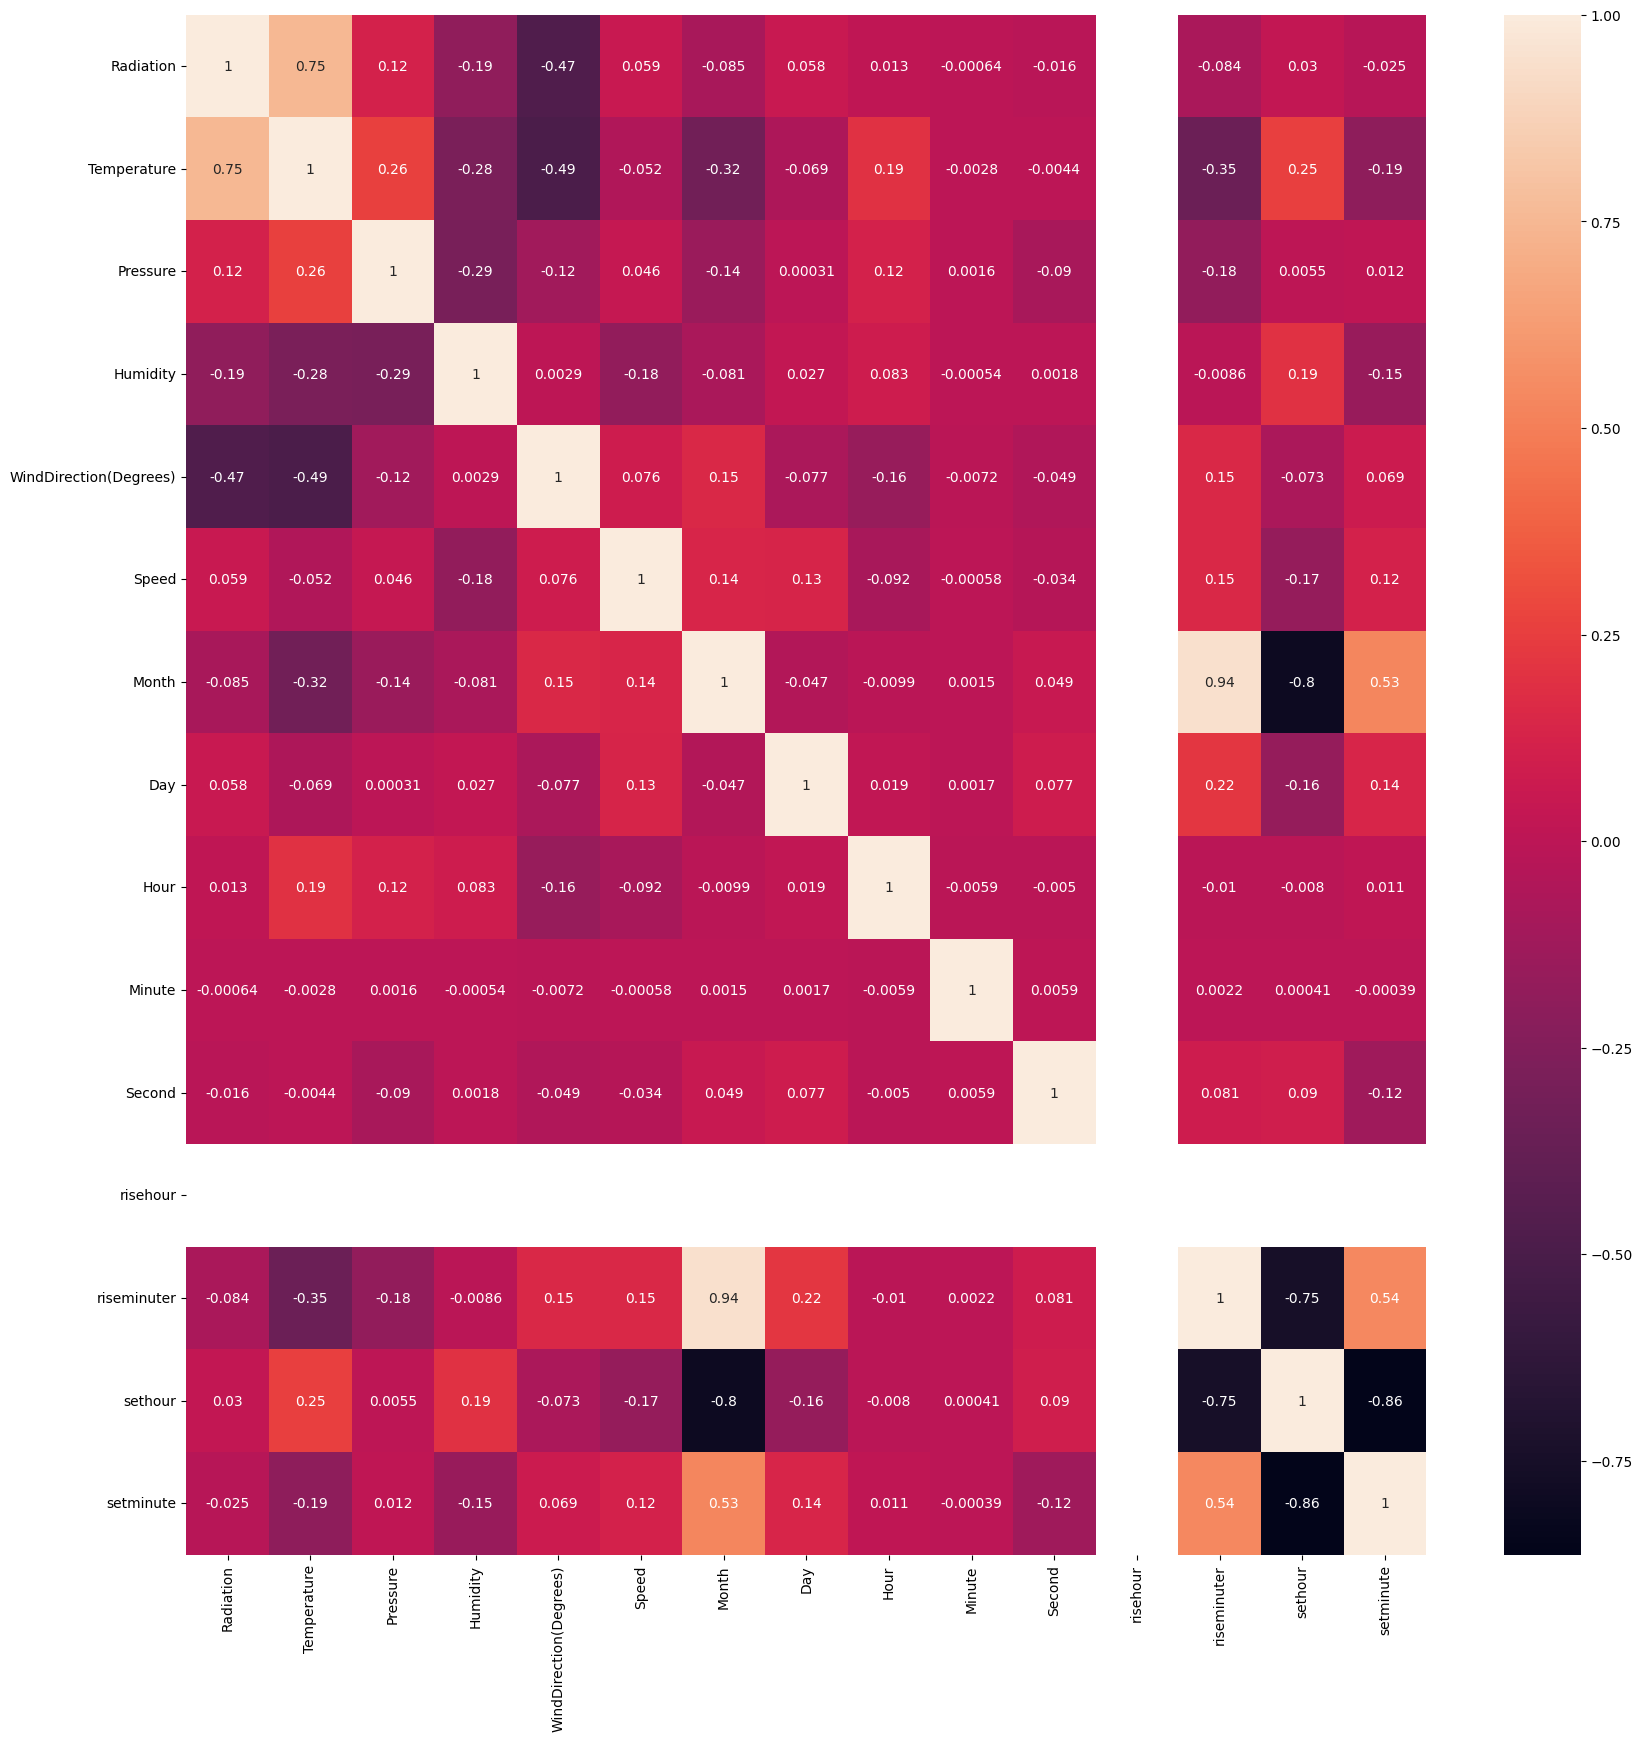

In [15]:
plt.figure(figsize=(20,20))
sns.heatmap(corr_matrix,annot=True)

# Feature selection using SelectKBest Meathod

In [16]:
bestfeatures = SelectKBest(score_func=f_regression, k=10)


In [17]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
train_y=label_encoder.fit_transform(target)

In [18]:
train_y

array([ 8,  8, 10, ...,  8,  7,  7], shape=(23932,))

In [19]:
target_reg = target


In [20]:
scaled_input_features = MinMaxScaler().fit_transform(input_features)
fit = bestfeatures.fit(scaled_input_features, target_reg)


In [21]:
fit.scores_

array([3.10842905e+04, 3.32432607e+02, 9.03494350e+02, 6.85732694e+03,
       8.42561472e+01, 1.73960426e+02, 8.01037664e+01, 4.11005785e+00,
       9.83052923e-03, 5.98204947e+00, 0.00000000e+00, 1.69698226e+02,
       2.15340821e+01, 1.44567277e+01])

In [22]:
scores=pd.DataFrame(fit.scores_)
column=pd.DataFrame(input_features.columns)

In [23]:
featureScores=pd.concat([column,scores],axis=1)
featureScores.columns=['Features','feature_imp']

In [24]:
featureScores.sort_values(by='feature_imp',ascending=False)

,Features,feature_imp
0,Temperature,31084.290503
3,WindDirection(Degrees),6857.326945
2,Humidity,903.494350
1,Pressure,332.432607
5,Month,173.960426
11,riseminuter,169.698226
4,Speed,84.256147
6,Day,80.103766
12,sethour,21.534082
13,setminute,14.456728


# Feature Selection using Using Extra Tree Classifier

In [25]:
model = ExtraTreesRegressor(n_estimators=100, random_state=42)
model.fit(scaled_input_features, target_reg)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the 

In [26]:
feature_importances = pd.DataFrame(model.feature_importances_,
                                   index=input_features.columns,
                                   columns=['feature_imp'])
feature_importances.sort_values(by='feature_imp',ascending=False,inplace=True)
perm_importance = permutation_importance(model, scaled_input_features, target_reg, n_repeats=10, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({
    'feature': input_features.columns,
    'importance': perm_importance.importances_mean
})
perm_df = perm_df.sort_values(by='importance', ascending=False)
print('Permutation Importance (regression):')
print(perm_df)
feature_importances


Permutation Importance (regression):
                   feature  importance
7                     Hour    0.924499
0              Temperature    0.340080
2                 Humidity    0.092505
6                      Day    0.023129
3   WindDirection(Degrees)    0.022357
8                   Minute    0.019275
5                    Month    0.016440
12                 sethour    0.015919
1                 Pressure    0.013276
13               setminute    0.010880
11             riseminuter    0.010042
9                   Second    0.007041
4                    Speed    0.004865
10                risehour    0.000000


,feature_imp
Temperature,0.385829
Hour,0.340347
WindDirection(Degrees),0.118239
Humidity,0.046173
Day,0.019569
Pressure,0.013802
riseminuter,0.012791
Minute,0.012570
setminute,0.012023
sethour,0.010915


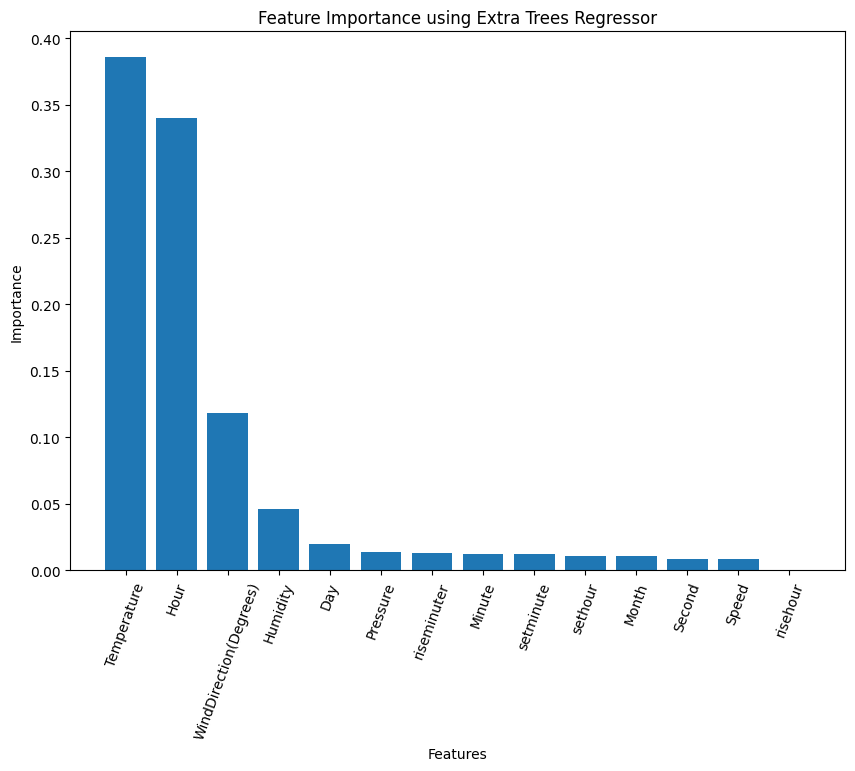

In [27]:
plt.figure(figsize=(10,7))
plt.bar(feature_importances.index, feature_importances['feature_imp'])
plt.xticks(rotation=70)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance using Extra Trees Regressor')
plt.show()


# Feature Engineering with BoxCox,Log,Min-Max & Standard Transformation

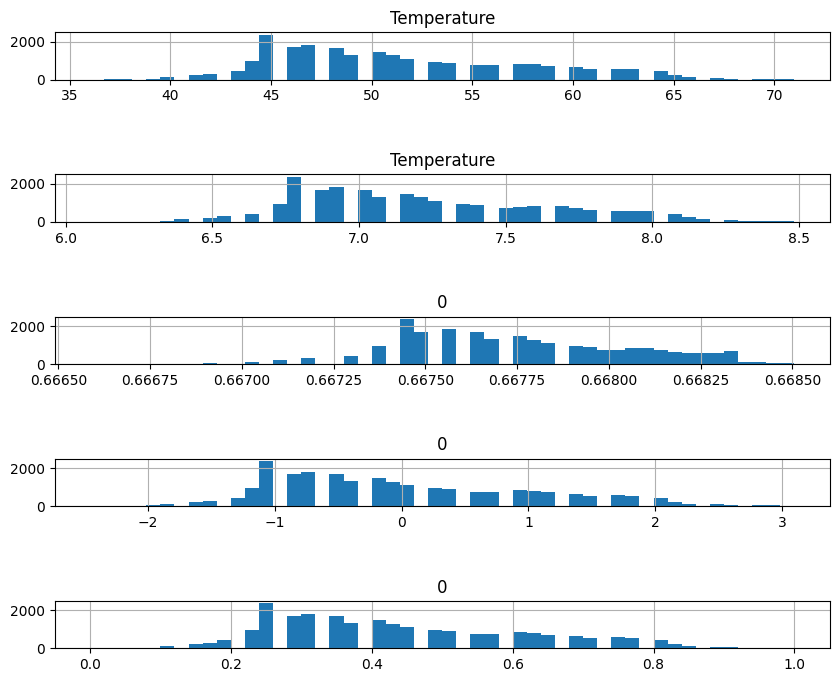

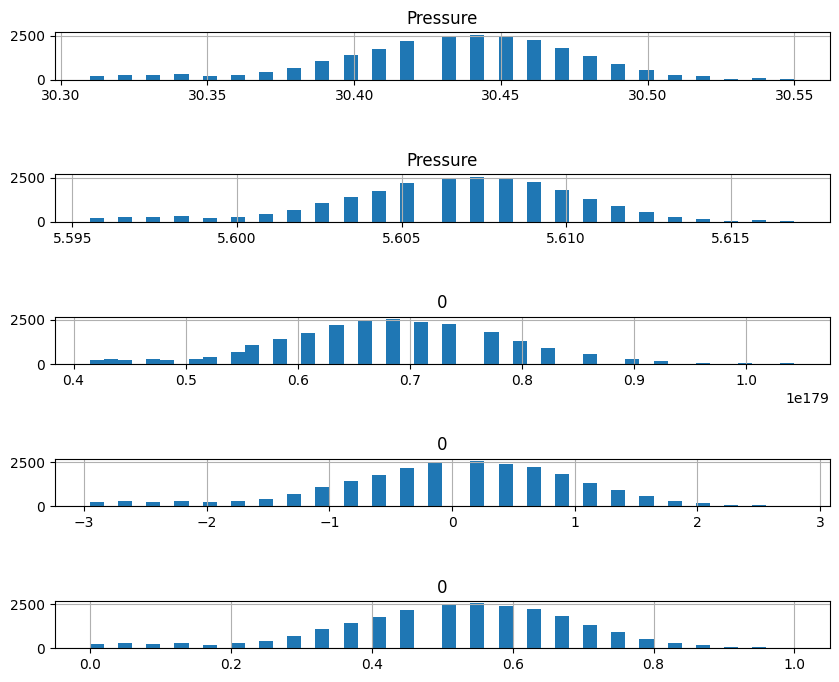

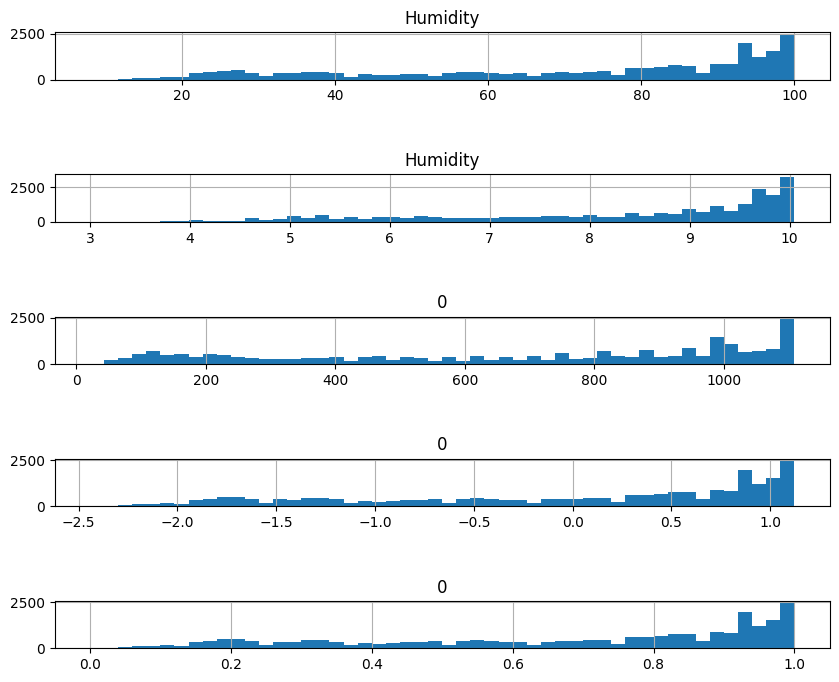

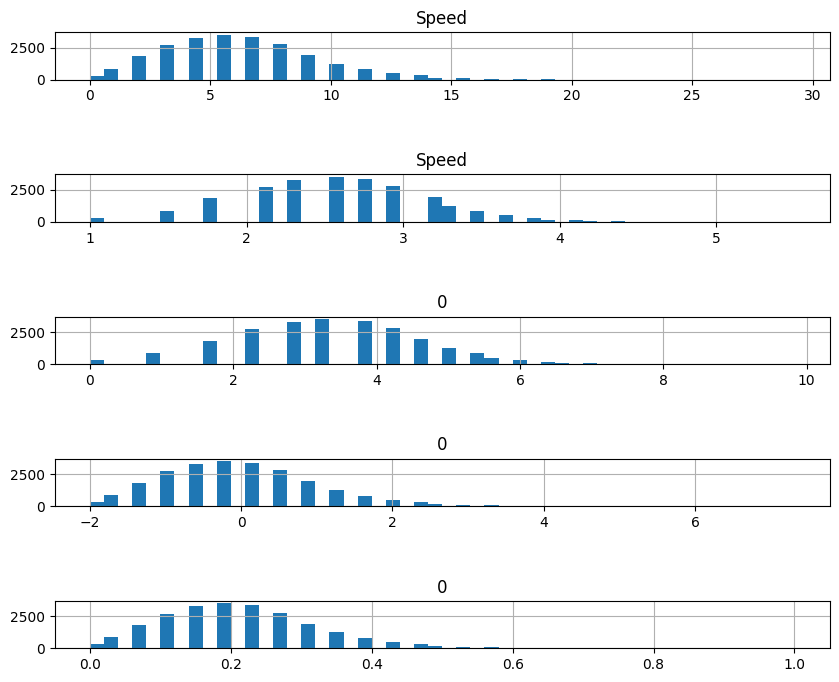

In [28]:
features_to_transform=['Temperature','Pressure','Humidity','Speed']
for i in features_to_transform:
    fig,(ax1,ax2,ax3,ax4,ax5)=plt.subplots(5,1,figsize=(10,8))
    pd.DataFrame(input_features[i]).hist(ax=ax1,bins=50)
    pd.DataFrame(np.sqrt(input_features[i]+1)).hist(ax=ax2,bins=50)
    pd.DataFrame(stats.boxcox(input_features[i]+1)[0]).hist(ax=ax3,bins=50)
    pd.DataFrame(StandardScaler().fit_transform(np.array(input_features[i]).reshape(-1,1))).hist(ax=ax4,bins=50)
    pd.DataFrame(MinMaxScaler().fit_transform(np.array(input_features[i]).reshape(-1,1))).hist(ax=ax5,bins=50)
    fig.subplots_adjust(hspace=2)

In [29]:
df["Wind_Combined"] = df["Speed"] * np.cos(np.deg2rad(df["WindDirection(Degrees)"]))
df = df.drop(columns=["WindDirection(Degrees)"])

input_features = df.drop(['Radiation'], axis=1)

transform = {
    'Temperature': np.sqrt(input_features['Temperature'] + 1),
    'Pressure': np.sqrt(input_features['Pressure'] + 1),
    'Humidity': np.sqrt(input_features['Humidity'] + 1)
}

for feature, series in transform.items():
    input_features[feature] = series

# Remove unwanted features
input_features.drop(columns=['Second', 'riseminuter', 'setminute'], inplace=True)

# Preparing data - Standardisation & Splitting

In [30]:
x_train, x_test, y_train, y_test =train_test_split(input_features,target,test_size=0.2,random_state=1)
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

# Model Comparison with Cross-Validation

In [31]:
# Handle NaN values that may result from transformations
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
x_train_clean = imputer.fit_transform(x_train)
x_test_clean = imputer.transform(x_test)

print("Data cleaning completed:")
print(f"Training set shape: {x_train_clean.shape}")
print(f"Test set shape: {x_test_clean.shape}")
print(f"NaN values in training set: {np.isnan(x_train_clean).sum()}")
print(f"NaN values in test set: {np.isnan(x_test_clean).sum()}")

Data cleaning completed:
Training set shape: (19145, 11)
Test set shape: (4787, 11)
NaN values in training set: 0
NaN values in test set: 0


Median (q50) → R²: 0.9209 | RMSE: 90.3193
80% PI coverage : 79.3%  (ideal: ~80%)
Mean interval width: 141.21 W/m²


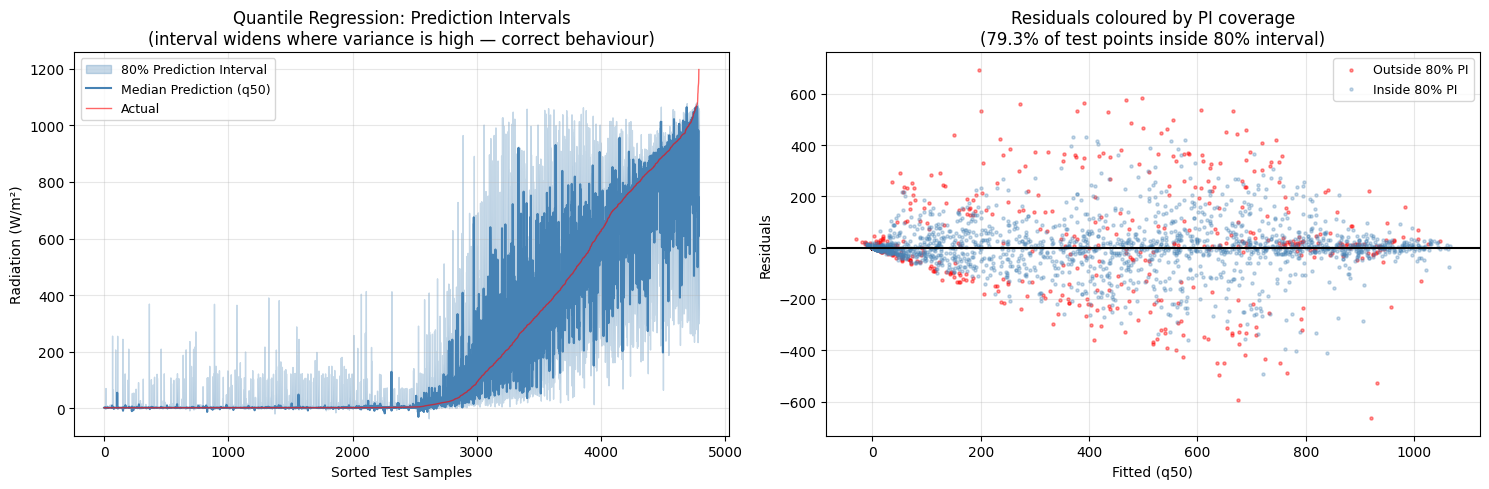

In [32]:
# ─── Quantile Regression: Model uncertainty instead of fighting it ────────────
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Train three models: lower bound, median, upper bound
quantile_models = {
    'q10': GradientBoostingRegressor(loss='quantile', alpha=0.10,
                                     n_estimators=300, max_depth=6,
                                     learning_rate=0.05, random_state=42),
    'q50': GradientBoostingRegressor(loss='quantile', alpha=0.50,
                                     n_estimators=300, max_depth=6,
                                     learning_rate=0.05, random_state=42),
    'q90': GradientBoostingRegressor(loss='quantile', alpha=0.90,
                                     n_estimators=300, max_depth=6,
                                     learning_rate=0.05, random_state=42),
}

for name, qm in quantile_models.items():
    qm.fit(x_train_clean, y_train)

pred_q10 = quantile_models['q10'].predict(x_test_clean)
pred_q50 = quantile_models['q50'].predict(x_test_clean)
pred_q90 = quantile_models['q90'].predict(x_test_clean)

y_test_arr = y_test.values

# Metrics on median prediction
rmse = np.sqrt(mean_squared_error(y_test_arr, pred_q50))
r2   = r2_score(y_test_arr, pred_q50)
coverage = np.mean((y_test_arr >= pred_q10) & (y_test_arr <= pred_q90)) * 100
interval_width = np.mean(pred_q90 - pred_q10)

print(f"Median (q50) → R²: {r2:.4f} | RMSE: {rmse:.4f}")
print(f"80% PI coverage : {coverage:.1f}%  (ideal: ~80%)")
print(f"Mean interval width: {interval_width:.2f} W/m²")

# ─── Plot: Actual vs Predicted with prediction interval ──────────────────────
sort_idx = np.argsort(y_test_arr)
y_sorted     = y_test_arr[sort_idx]
q10_sorted   = pred_q10[sort_idx]
q50_sorted   = pred_q50[sort_idx]
q90_sorted   = pred_q90[sort_idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: prediction intervals
ax = axes[0]
ax.fill_between(range(len(y_sorted)), q10_sorted, q90_sorted,
                alpha=0.3, color='steelblue', label='80% Prediction Interval')
ax.plot(q50_sorted, color='steelblue', lw=1.5, label='Median Prediction (q50)')
ax.plot(y_sorted,   color='red',       lw=1,   alpha=0.6, label='Actual')
ax.set_xlabel('Sorted Test Samples')
ax.set_ylabel('Radiation (W/m²)')
ax.set_title('Quantile Regression: Prediction Intervals\n(interval widens where variance is high — correct behaviour)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Right: residuals of median — should still fan, but intervals capture it
ax2 = axes[1]
residuals_q50 = y_test_arr - pred_q50
in_interval = (y_test_arr >= pred_q10) & (y_test_arr <= pred_q90)
ax2.scatter(pred_q50[~in_interval], residuals_q50[~in_interval],
            alpha=0.4, s=5, color='red',      label='Outside 80% PI')
ax2.scatter(pred_q50[in_interval],  residuals_q50[in_interval],
            alpha=0.3, s=5, color='steelblue', label='Inside 80% PI')
ax2.axhline(0, color='black', lw=1.5)
ax2.set_xlabel('Fitted (q50)')
ax2.set_ylabel('Residuals')
ax2.set_title(f'Residuals coloured by PI coverage\n({coverage:.1f}% of test points inside 80% interval)')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold

# Store results for all models
results = []

# Define models
models_dict = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'XGBoost': XGBRegressor(learning_rate=0.1, max_depth=8, random_state=42)
}

# Setup cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Train and evaluate each model
for model_name, model in models_dict.items():
    # Cross-validation scores
    cv_scores = cross_val_score(model, x_train_clean, y_train, cv=kfold, scoring='r2')
    
    # Train model on full training set
    model.fit(x_train_clean, y_train)
    
    # Make predictions
    y_pred_model = model.predict(x_test_clean)
    
    # Calculate metrics
    rmse_model = np.sqrt(mean_squared_error(y_test, y_pred_model))
    mae_model = median_absolute_error(y_test, y_pred_model)
    r2_model = r2_score(y_test, y_pred_model)
    
    # Store results
    results.append({
        'Model': model_name,
        'RMSE': rmse_model,
        'MAE': mae_model,
        'R² Score': r2_model,
        'CV Mean R²': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'CV Scores': cv_scores
    })
    
    print(f"\n{model_name}:")
    print(f"  RMSE: {rmse_model:.4f}")
    print(f"  MAE: {mae_model:.4f}")
    print(f"  R² Score: {r2_model:.4f}")
    print(f"  CV R² (Mean ± Std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


Linear Regression:
  RMSE: 185.2489
  MAE: 102.9281
  R² Score: 0.6671
  CV R² (Mean ± Std): 0.6737 ± 0.0035

Ridge Regression:
  RMSE: 185.2490
  MAE: 102.9258
  R² Score: 0.6671
  CV R² (Mean ± Std): 0.6737 ± 0.0035

Lasso Regression:
  RMSE: 185.2473
  MAE: 102.7046
  R² Score: 0.6671
  CV R² (Mean ± Std): 0.6737 ± 0.0035

Random Forest:
  RMSE: 76.0747
  MAE: 0.3469
  R² Score: 0.9439
  CV R² (Mean ± Std): 0.9401 ± 0.0035

Gradient Boosting:
  RMSE: 105.7040
  MAE: 18.1458
  R² Score: 0.8916
  CV R² (Mean ± Std): 0.8914 ± 0.0045

XGBoost:
  RMSE: 75.9835
  MAE: 3.5157
  R² Score: 0.9440
  CV R² (Mean ± Std): 0.9391 ± 0.0043


In [34]:
# Create comparison DataFrame
comparison_df = pd.DataFrame([
    {
        'Model': r['Model'],
        'RMSE': f"{r['RMSE']:.4f}",
        'MAE': f"{r['MAE']:.4f}",
        'R² Score': f"{r['R² Score']:.4f}",
        'CV Mean R²': f"{r['CV Mean R²']:.4f}",
        'CV Std': f"{r['CV Std']:.4f}"
    }
    for r in results
])

print("\n" + "="*100)
print("MODEL COMPARISON TABLE")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)


MODEL COMPARISON TABLE
            Model     RMSE      MAE R² Score CV Mean R² CV Std
Linear Regression 185.2489 102.9281   0.6671     0.6737 0.0035
 Ridge Regression 185.2490 102.9258   0.6671     0.6737 0.0035
 Lasso Regression 185.2473 102.7046   0.6671     0.6737 0.0035
    Random Forest  76.0747   0.3469   0.9439     0.9401 0.0035
Gradient Boosting 105.7040  18.1458   0.8916     0.8914 0.0045
          XGBoost  75.9835   3.5157   0.9440     0.9391 0.0043


In [35]:
# Find best model based on lowest RMSE, then lowest MAE
best_model_idx = min(range(len(results)), key=lambda i: (results[i]['RMSE'], results[i]['MAE']))
best_model_info = results[best_model_idx]

print("\n" + "="*100)
print("BEST MODEL ANALYSIS")
print("="*100)
print(f"Best Model: {best_model_info['Model']}")
print(f"  • RMSE: {best_model_info['RMSE']:.4f}")
print(f"  • MAE: {best_model_info['MAE']:.4f}")
print(f"  • R² Score: {best_model_info['R² Score']:.4f}")
print(f"  • Cross-Validation R² (Mean): {best_model_info['CV Mean R²']:.4f}")
print(f"  • Cross-Validation R² (Std): {best_model_info['CV Std']:.4f}")
print(f"  • Individual CV Scores: {[f'{score:.4f}' for score in best_model_info['CV Scores']]}")
print("="*100)


BEST MODEL ANALYSIS
Best Model: XGBoost
  • RMSE: 75.9835
  • MAE: 3.5157
  • R² Score: 0.9440
  • Cross-Validation R² (Mean): 0.9391
  • Cross-Validation R² (Std): 0.0043
  • Individual CV Scores: ['0.9394', '0.9435', '0.9309', '0.9402', '0.9413']


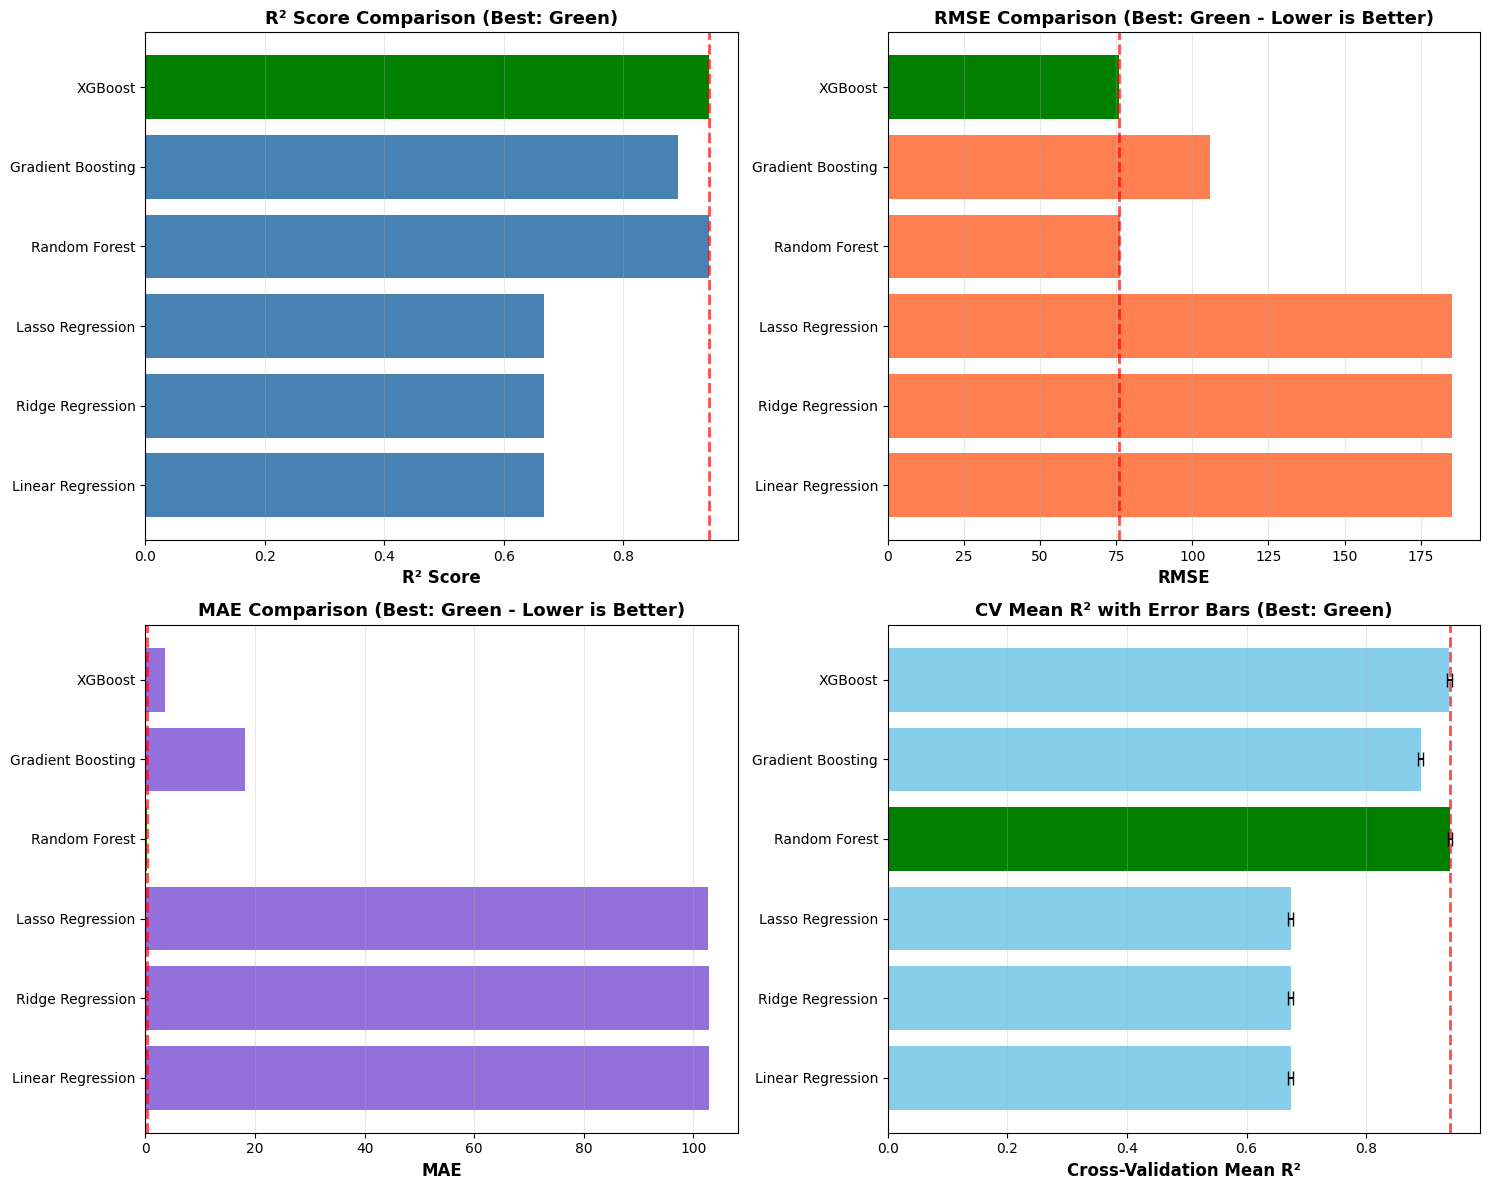

In [36]:
# Visualization 1: R² Score Comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# R² Score Comparison
ax1 = axes[0, 0]
models = [r['Model'] for r in results]
r2_scores = [r['R² Score'] for r in results]
colors = ['green' if r['R² Score'] == max(r2_scores) else 'steelblue' for r in results]
ax1.barh(models, r2_scores, color=colors)
ax1.set_xlabel('R² Score', fontsize=12, fontweight='bold')
ax1.set_title('R² Score Comparison (Best: Green)', fontsize=13, fontweight='bold')
ax1.axvline(x=max(r2_scores), color='red', linestyle='--', linewidth=2, alpha=0.7)
ax1.grid(axis='x', alpha=0.3)

# RMSE Comparison
ax2 = axes[0, 1]
rmse_scores = [r['RMSE'] for r in results]
colors_rmse = ['green' if r['RMSE'] == min(rmse_scores) else 'coral' for r in results]
ax2.barh(models, rmse_scores, color=colors_rmse)
ax2.set_xlabel('RMSE', fontsize=12, fontweight='bold')
ax2.set_title('RMSE Comparison (Best: Green - Lower is Better)', fontsize=13, fontweight='bold')
ax2.axvline(x=min(rmse_scores), color='red', linestyle='--', linewidth=2, alpha=0.7)
ax2.grid(axis='x', alpha=0.3)

# MAE Comparison
ax3 = axes[1, 0]
mae_scores = [r['MAE'] for r in results]
colors_mae = ['green' if r['MAE'] == min(mae_scores) else 'mediumpurple' for r in results]
ax3.barh(models, mae_scores, color=colors_mae)
ax3.set_xlabel('MAE', fontsize=12, fontweight='bold')
ax3.set_title('MAE Comparison (Best: Green - Lower is Better)', fontsize=13, fontweight='bold')
ax3.axvline(x=min(mae_scores), color='red', linestyle='--', linewidth=2, alpha=0.7)
ax3.grid(axis='x', alpha=0.3)

# Cross-Validation R² Comparison
ax4 = axes[1, 1]
cv_means = [r['CV Mean R²'] for r in results]
cv_stds = [r['CV Std'] for r in results]
colors_cv = ['green' if r['CV Mean R²'] == max(cv_means) else 'skyblue' for r in results]
ax4.barh(models, cv_means, xerr=cv_stds, color=colors_cv, capsize=5)
ax4.set_xlabel('Cross-Validation Mean R²', fontsize=12, fontweight='bold')
ax4.set_title('CV Mean R² with Error Bars (Best: Green)', fontsize=13, fontweight='bold')
ax4.axvline(x=max(cv_means), color='red', linestyle='--', linewidth=2, alpha=0.7)
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

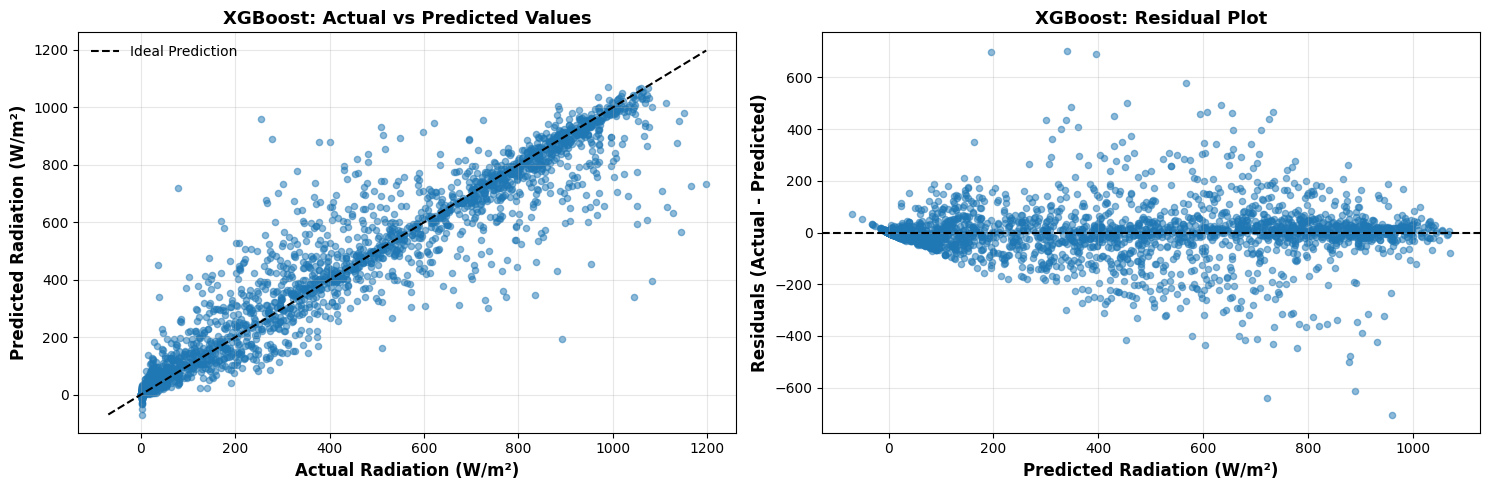

In [37]:
# Train best model and visualize predictions
best_model_name = best_model_info['Model']
best_model_obj = models_dict[best_model_name]
best_model_obj.fit(x_train_clean, y_train)
best_y_pred = best_model_obj.predict(x_test_clean)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Actual vs Predicted
ax1 = axes[0]
ax1.scatter(y_test, best_y_pred, alpha=0.5, s=20)
min_val = min(y_test.min(), best_y_pred.min())
max_val = max(y_test.max(), best_y_pred.max())
ax1.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=1.5, label='Ideal Prediction')
ax1.set_xlabel('Actual Radiation (W/m²)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Predicted Radiation (W/m²)', fontsize=12, fontweight='bold')
ax1.set_title(f'{best_model_name}: Actual vs Predicted Values', fontsize=13, fontweight='bold')
ax1.legend(frameon=False)
ax1.grid(alpha=0.3)

# Residuals
ax2 = axes[1]
residuals = y_test - best_y_pred
ax2.scatter(best_y_pred, residuals, alpha=0.5, s=20)
ax2.axhline(y=0, color='black', linestyle='--', lw=1.5)
ax2.set_xlabel('Predicted Radiation (W/m²)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Residuals (Actual - Predicted)', fontsize=12, fontweight='bold')
ax2.set_title(f'{best_model_name}: Residual Plot', fontsize=13, fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
# Advanced & Latest Regression Models for Better Prediction
print("\n" + "="*100)
print("TESTING ADVANCED & LATEST REGRESSION MODELS")
print("="*100)

from sklearn.linear_model import ElasticNet, HuberRegressor, SGDRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import AdaBoostRegressor, VotingRegressor, StackingRegressor
try:
    import lightgbm as lgb
    lightgbm_available = True
except ImportError:
    lightgbm_available = False
    print("Warning: LightGBM not installed. Install with: pip install lightgbm")

advanced_results = []

advanced_models_dict = {}

advanced_models_dict['ElasticNet'] = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)

advanced_models_dict['Huber Regressor'] = HuberRegressor(max_iter=5000, epsilon=1.35, alpha=0.0001)

advanced_models_dict['SGD Regressor'] = SGDRegressor(loss='squared_error', penalty='l2', 
                                                      learning_rate='optimal', random_state=42, max_iter=5000)

advanced_models_dict['MLP Neural Network'] = MLPRegressor(hidden_layer_sizes=(100, 50, 25), 
                                                           activation='relu', solver='adam', 
                                                           learning_rate='adaptive', max_iter=1000, 
                                                           random_state=42, early_stopping=True, 
                                                           validation_fraction=0.1)

advanced_models_dict['AdaBoost Regressor'] = AdaBoostRegressor(n_estimators=100, learning_rate=0.1, 
                                                                random_state=42, loss='linear')

if lightgbm_available:
    advanced_models_dict['LightGBM'] = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, 
                                                         num_leaves=31, random_state=42, verbose=-1, n_jobs=-1)

for model_name, model in advanced_models_dict.items():
    try:
        # Cross-validation scores
        cv_scores = cross_val_score(model, x_train_clean, y_train, cv=kfold, scoring='r2', n_jobs=-1)
        
        # Train model on full training set
        model.fit(x_train_clean, y_train)
        
        # Make predictions
        y_pred_adv = model.predict(x_test_clean)
        
        # Calculate metrics
        rmse_adv = np.sqrt(mean_squared_error(y_test, y_pred_adv))
        mae_adv = median_absolute_error(y_test, y_pred_adv)
        r2_adv = r2_score(y_test, y_pred_adv)
        
        # Store results
        advanced_results.append({
            'Model': model_name,
            'RMSE': rmse_adv,
            'MAE': mae_adv,
            'R² Score': r2_adv,
            'CV Mean R²': cv_scores.mean(),
            'CV Std': cv_scores.std(),
            'CV Scores': cv_scores,
            'Status': 'Success'
        })
        
        print(f"\n✓ {model_name}:")
        print(f"  RMSE: {rmse_adv:.4f}")
        print(f"  MAE: {mae_adv:.4f}")
        print(f"  R² Score: {r2_adv:.4f}")
        print(f"  CV R² (Mean ± Std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
        
    except Exception as e:
        print(f"\n✗ {model_name}: Failed - {str(e)[:50]}")
        advanced_results.append({
            'Model': model_name,
            'RMSE': None,
            'MAE': None,
            'R² Score': None,
            'CV Mean R²': None,
            'CV Std': None,
            'Status': f'Failed: {str(e)[:30]}'
        })

# Combine original and advanced results
all_results_combined = results + advanced_results

print("\n" + "="*100)
print("ALL MODELS COMPARISON (Original + Advanced)")
print("="*100)

comparison_all_df = pd.DataFrame([
    {
        'Model': r['Model'],
        'RMSE': f"{r['RMSE']:.4f}" if r['RMSE'] is not None else "N/A",
        'MAE': f"{r['MAE']:.4f}" if r['MAE'] is not None else "N/A",
        'R² Score': f"{r['R² Score']:.4f}" if r['R² Score'] is not None else "N/A",
        'CV Mean R²': f"{r['CV Mean R²']:.4f}" if r['CV Mean R²'] is not None else "N/A",
        'CV Std': f"{r['CV Std']:.4f}" if r['CV Std'] is not None else "N/A"
    }
    for r in all_results_combined if r.get('Status', 'Success') == 'Success'
])

print(comparison_all_df.to_string(index=False))
print("="*100)


TESTING ADVANCED & LATEST REGRESSION MODELS

✓ ElasticNet:
  RMSE: 185.9159
  MAE: 100.0622
  R² Score: 0.6647
  CV R² (Mean ± Std): 0.6717 ± 0.0030

✓ Huber Regressor:
  RMSE: 187.5812
  MAE: 94.0336
  R² Score: 0.6586
  CV R² (Mean ± Std): 0.6666 ± 0.0031

✓ SGD Regressor:
  RMSE: 189.5313
  MAE: 106.6176
  R² Score: 0.6515
  CV R² (Mean ± Std): 0.6583 ± 0.0090

✓ MLP Neural Network:
  RMSE: 83.8915
  MAE: 2.8505
  R² Score: 0.9317
  CV R² (Mean ± Std): 0.9241 ± 0.0061

✓ AdaBoost Regressor:
  RMSE: 131.1778
  MAE: 30.3715
  R² Score: 0.8331
  CV R² (Mean ± Std): 0.8367 ± 0.0029

✓ LightGBM:
  RMSE: 79.2256
  MAE: 4.4448
  R² Score: 0.9391
  CV R² (Mean ± Std): 0.9367 ± 0.0037

ALL MODELS COMPARISON (Original + Advanced)
             Model     RMSE      MAE R² Score CV Mean R² CV Std
 Linear Regression 185.2489 102.9281   0.6671     0.6737 0.0035
  Ridge Regression 185.2490 102.9258   0.6671     0.6737 0.0035
  Lasso Regression 185.2473 102.7046   0.6671     0.6737 0.0035
     Rando

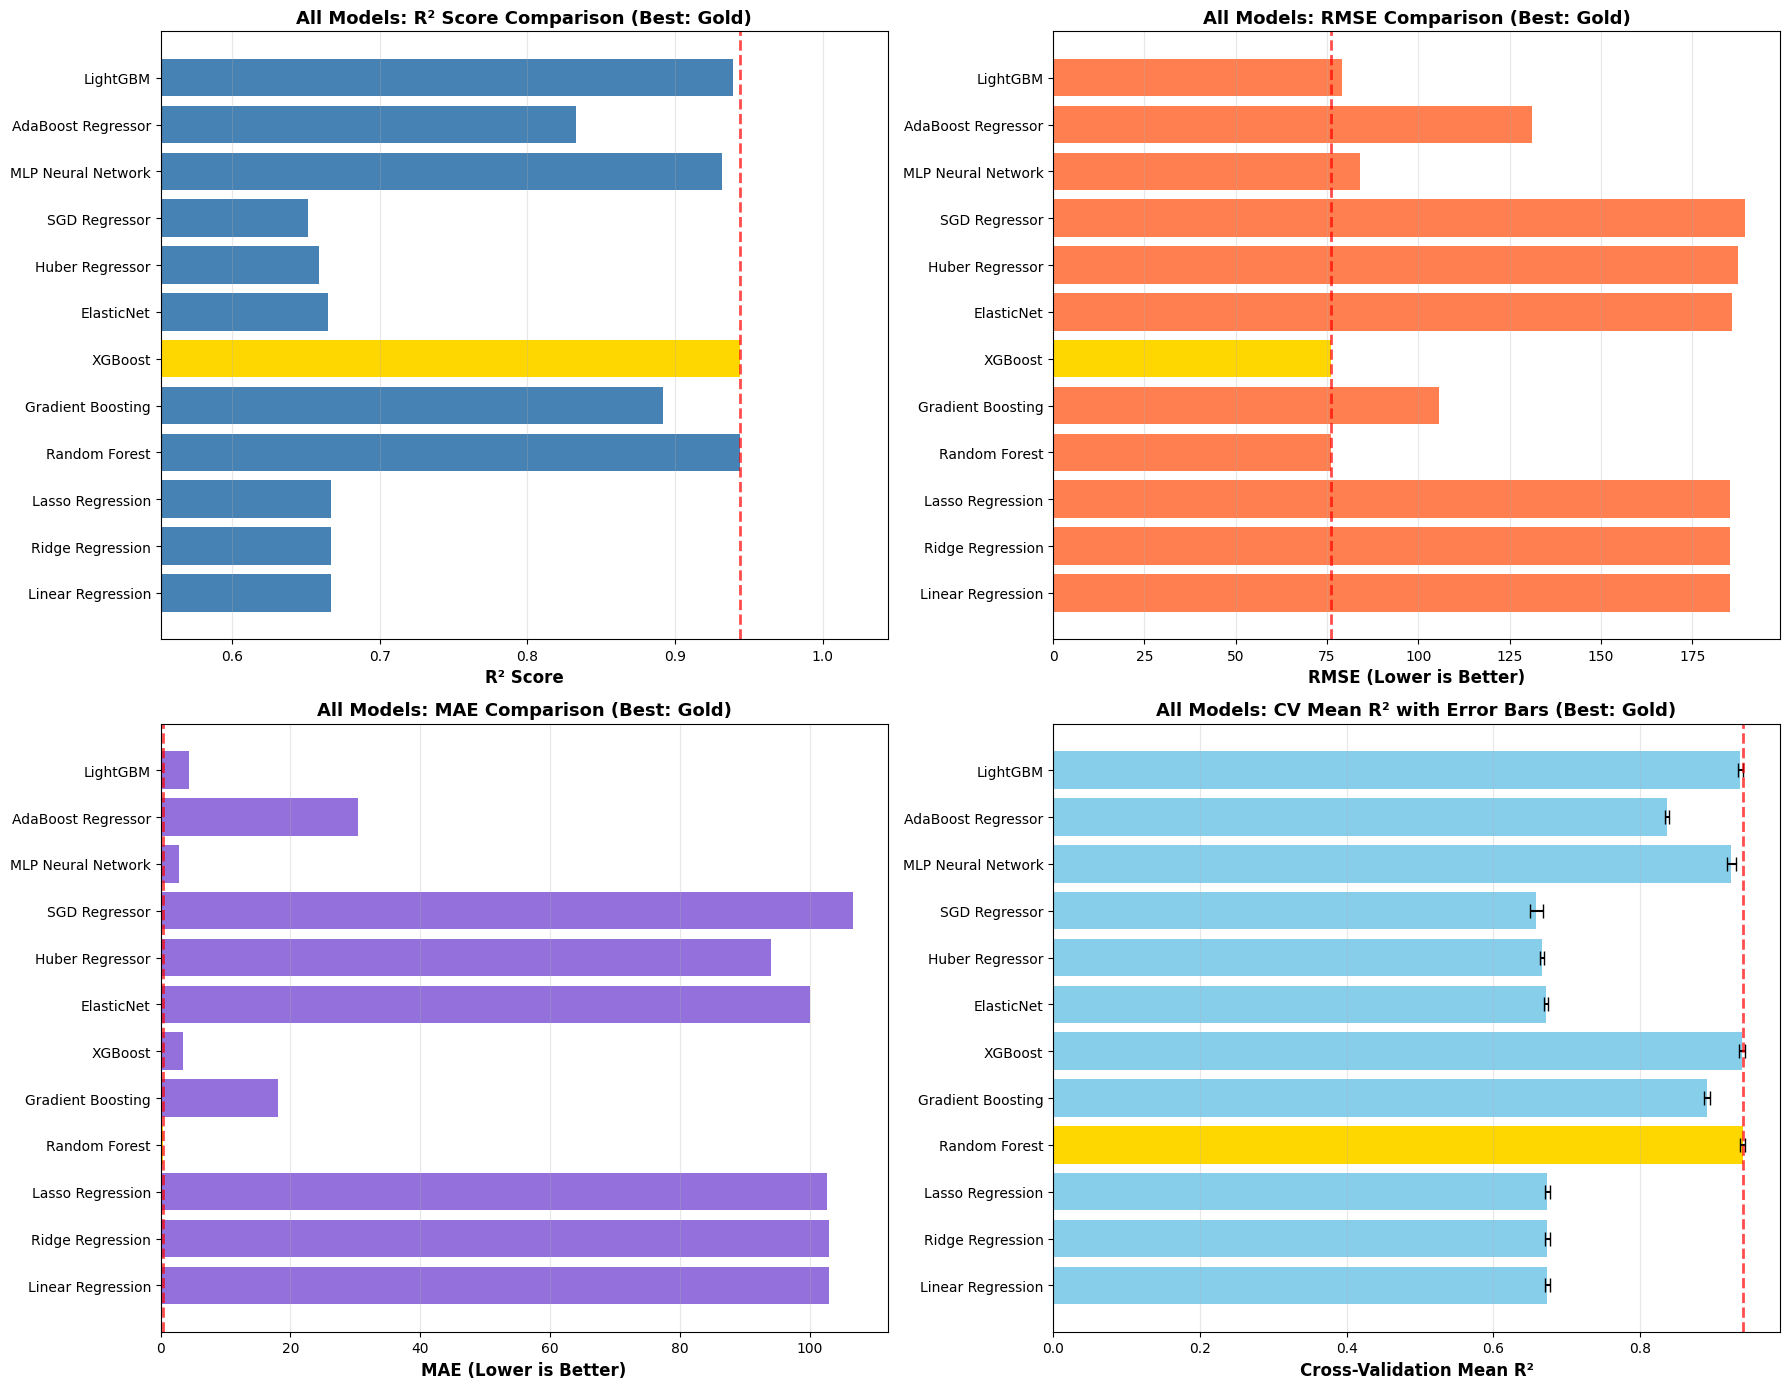


COMPREHENSIVE MODEL RANKING (All Models)
 Rank              Model R² Score   RMSE      MAE CV R² Mean Status
    1            XGBoost   0.9440  75.98   3.5157     0.9391  ⭐ TOP
    2      Random Forest   0.9439  76.07   0.3469     0.9401      ✓
    3           LightGBM   0.9391  79.23   4.4448     0.9367      ✓
    4 MLP Neural Network   0.9317  83.89   2.8505     0.9241      ✓
    5  Gradient Boosting   0.8916 105.70  18.1458     0.8914      ✓
    6 AdaBoost Regressor   0.8331 131.18  30.3715     0.8367      ✓
    7   Lasso Regression   0.6671 185.25 102.7046     0.6737      ✓
    8  Linear Regression   0.6671 185.25 102.9281     0.6737      ✓
    9   Ridge Regression   0.6671 185.25 102.9258     0.6737      ✓
   10         ElasticNet   0.6647 185.92 100.0622     0.6717      ✓
   11    Huber Regressor   0.6586 187.58  94.0336     0.6666      ✓
   12      SGD Regressor   0.6515 189.53 106.6176     0.6583      ✓


In [39]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

successful_results = [r for r in all_results_combined if r.get('Status', 'Success') == 'Success']

# R² Score Comparison
ax1 = axes[0, 0]
models_all = [r['Model'] for r in successful_results]
r2_scores_all = [r['R² Score'] for r in successful_results]
colors_r2 = ['gold' if r['R² Score'] == max(r2_scores_all) else 'steelblue' for r in successful_results]
ax1.barh(models_all, r2_scores_all, color=colors_r2)
ax1.set_xlabel('R² Score', fontsize=12, fontweight='bold')
ax1.set_title('All Models: R² Score Comparison (Best: Gold)', fontsize=13, fontweight='bold')
ax1.axvline(x=max(r2_scores_all), color='red', linestyle='--', linewidth=2, alpha=0.7)
ax1.grid(axis='x', alpha=0.3)
ax1.set_xlim([min(r2_scores_all) - 0.1, max(r2_scores_all) + 0.1])

# RMSE Comparison
ax2 = axes[0, 1]
rmse_scores_all = [r['RMSE'] for r in successful_results]
colors_rmse_all = ['gold' if r['RMSE'] == min(rmse_scores_all) else 'coral' for r in successful_results]
ax2.barh(models_all, rmse_scores_all, color=colors_rmse_all)
ax2.set_xlabel('RMSE (Lower is Better)', fontsize=12, fontweight='bold')
ax2.set_title('All Models: RMSE Comparison (Best: Gold)', fontsize=13, fontweight='bold')
ax2.axvline(x=min(rmse_scores_all), color='red', linestyle='--', linewidth=2, alpha=0.7)
ax2.grid(axis='x', alpha=0.3)

# MAE Comparison
ax3 = axes[1, 0]
mae_scores_all = [r['MAE'] for r in successful_results]
colors_mae_all = ['gold' if r['MAE'] == min(mae_scores_all) else 'mediumpurple' for r in successful_results]
ax3.barh(models_all, mae_scores_all, color=colors_mae_all)
ax3.set_xlabel('MAE (Lower is Better)', fontsize=12, fontweight='bold')
ax3.set_title('All Models: MAE Comparison (Best: Gold)', fontsize=13, fontweight='bold')
ax3.axvline(x=min(mae_scores_all), color='red', linestyle='--', linewidth=2, alpha=0.7)
ax3.grid(axis='x', alpha=0.3)

# Cross-Validation R² Comparison
ax4 = axes[1, 1]
cv_means_all = [r['CV Mean R²'] for r in successful_results]
cv_stds_all = [r['CV Std'] for r in successful_results]
colors_cv_all = ['gold' if r['CV Mean R²'] == max(cv_means_all) else 'skyblue' for r in successful_results]
ax4.barh(models_all, cv_means_all, xerr=cv_stds_all, color=colors_cv_all, capsize=5)
ax4.set_xlabel('Cross-Validation Mean R²', fontsize=12, fontweight='bold')
ax4.set_title('All Models: CV Mean R² with Error Bars (Best: Gold)', fontsize=13, fontweight='bold')
ax4.axvline(x=max(cv_means_all), color='red', linestyle='--', linewidth=2, alpha=0.7)
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*100)
print("COMPREHENSIVE MODEL RANKING (All Models)")
print("="*100)

ranking_df = pd.DataFrame([
    {
        'Rank': i+1,
        'Model': r['Model'],
        'R² Score': f"{r['R² Score']:.4f}",
        'RMSE': f"{r['RMSE']:.2f}",
        'MAE': f"{r['MAE']:.4f}",
        'CV R² Mean': f"{r['CV Mean R²']:.4f}",
        'Status': '⭐ TOP' if r['R² Score'] == max(r2_scores_all) else '✓'
    }
    for i, r in enumerate(sorted(successful_results, key=lambda x: x['R² Score'], reverse=True))
])

print(ranking_df.to_string(index=False))
print("="*100)

In [40]:
# Ensemble Methods - Combining Multiple Models for Better Predictions
print("\n" + "="*100)
print("ENSEMBLE METHODS: VOTING & STACKING REGRESSORS")
print("="*100)

# Define base estimators for ensemble methods
base_estimators = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('gb', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)),
    ('xgb', XGBRegressor(learning_rate=0.1, max_depth=8, random_state=42)),
    ('ridge', Ridge(alpha=1.0))
]

ensemble_results = []

# 1. Voting Regressor (Average)
print("\n1. Training Voting Regressor (Average)...")
voting_reg = VotingRegressor(estimators=base_estimators)
cv_scores_voting = cross_val_score(voting_reg, x_train_clean, y_train, cv=kfold, scoring='r2', n_jobs=-1)
voting_reg.fit(x_train_clean, y_train)
y_pred_voting = voting_reg.predict(x_test_clean)
rmse_voting = np.sqrt(mean_squared_error(y_test, y_pred_voting))
mae_voting = median_absolute_error(y_test, y_pred_voting)
r2_voting = r2_score(y_test, y_pred_voting)

ensemble_results.append({
    'Model': 'Voting Regressor (Average)',
    'RMSE': rmse_voting,
    'MAE': mae_voting,
    'R² Score': r2_voting,
    'CV Mean R²': cv_scores_voting.mean(),
    'CV Std': cv_scores_voting.std()
})

print(f"   R² Score: {r2_voting:.4f}")
print(f"   RMSE: {rmse_voting:.4f}")
print(f"   CV Mean R²: {cv_scores_voting.mean():.4f} ± {cv_scores_voting.std():.4f}")

# 2. Stacking Regressor (using a meta-regressor)
print("\n2. Training Stacking Regressor (with Ridge meta-regressor)...")
stacking_reg = StackingRegressor(
    estimators=base_estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=5
)
cv_scores_stacking = cross_val_score(stacking_reg, x_train_clean, y_train, cv=kfold, scoring='r2', n_jobs=-1)
stacking_reg.fit(x_train_clean, y_train)
y_pred_stacking = stacking_reg.predict(x_test_clean)
rmse_stacking = np.sqrt(mean_squared_error(y_test, y_pred_stacking))
mae_stacking = median_absolute_error(y_test, y_pred_stacking)
r2_stacking = r2_score(y_test, y_pred_stacking)

ensemble_results.append({
    'Model': 'Stacking Regressor',
    'RMSE': rmse_stacking,
    'MAE': mae_stacking,
    'R² Score': r2_stacking,
    'CV Mean R²': cv_scores_stacking.mean(),
    'CV Std': cv_scores_stacking.std()
})

print(f"   R² Score: {r2_stacking:.4f}")
print(f"   RMSE: {rmse_stacking:.4f}")
print(f"   CV Mean R²: {cv_scores_stacking.mean():.4f} ± {cv_scores_stacking.std():.4f}")

# Combine all final results
all_final_results = successful_results + ensemble_results

print("\n" + "="*100)
print("FINAL RANKING: ALL MODELS + ADVANCED + ENSEMBLE")
print("="*100)

final_ranking_df = pd.DataFrame([
    {
        'Rank': i+1,
        'Model': r['Model'],
        'R² Score': f"{r['R² Score']:.4f}",
        'RMSE': f"{r['RMSE']:.2f}",
        'MAE': f"{r['MAE']:.4f}",
        'CV Mean R²': f"{r['CV Mean R²']:.4f}",
        'Type': 'Ensemble' if 'Voting' in r['Model'] or 'Stacking' in r['Model'] else 'Advanced' if r['Model'] not in [orig['Model'] for orig in results] else 'Original'
    }
    for i, r in enumerate(sorted(all_final_results, key=lambda x: (x['RMSE'], x['MAE'])), 1)
])

print(final_ranking_df.to_string(index=False))
print("="*100)

# Identify best model overall by RMSE and MAE
best_overall = min(all_final_results, key=lambda x: (x['RMSE'], x['MAE']))
print(f"🏆 BEST MODEL OVERALL: {best_overall['Model']}")
print(f"   RMSE: {best_overall['RMSE']:.4f}")
print(f"   MAE: {best_overall['MAE']:.4f}")
print(f"   R² Score: {best_overall['R² Score']:.4f}")
print("="*100)
# Save the final deployed model object
best_deployed_model_name = best_overall['Model']
if best_deployed_model_name in models_dict:
    best_deployed_model = models_dict[best_deployed_model_name]
elif best_deployed_model_name in advanced_models_dict:
    best_deployed_model = advanced_models_dict[best_deployed_model_name]
elif best_deployed_model_name == 'Voting Regressor (Average)':
    best_deployed_model = voting_reg
elif best_deployed_model_name == 'Stacking Regressor':
    best_deployed_model = stacking_reg
else:
    best_deployed_model = None

if best_deployed_model is not None:
    best_deployed_model.fit(x_train_clean, y_train)
    joblib.dump(best_deployed_model, 'best_solar_radiation_model.joblib')
    print(f"Saved deployed model to best_solar_radiation_model.joblib")
else:
    print("Could not serialize best model; the model object was not found.")
print("="*100)



ENSEMBLE METHODS: VOTING & STACKING REGRESSORS

1. Training Voting Regressor (Average)...
   R² Score: 0.9148
   RMSE: 93.6865
   CV Mean R²: 0.9128 ± 0.0040

2. Training Stacking Regressor (with Ridge meta-regressor)...
   R² Score: 0.9463
   RMSE: 74.4298
   CV Mean R²: 0.9419 ± 0.0038

FINAL RANKING: ALL MODELS + ADVANCED + ENSEMBLE
 Rank                      Model R² Score   RMSE      MAE CV Mean R²     Type
    2         Stacking Regressor   0.9463  74.43   2.2656     0.9419 Ensemble
    3                    XGBoost   0.9440  75.98   3.5157     0.9391 Original
    4              Random Forest   0.9439  76.07   0.3469     0.9401 Original
    5                   LightGBM   0.9391  79.23   4.4448     0.9367 Advanced
    6         MLP Neural Network   0.9317  83.89   2.8505     0.9241 Advanced
    7 Voting Regressor (Average)   0.9148  93.69  31.5424     0.9128 Ensemble
    8          Gradient Boosting   0.8916 105.70  18.1458     0.8914 Original
    9         AdaBoost Regressor   0.

BEST MODEL DEEP DIVE ANALYSIS
Analyzing: Stacking Regressor
R² Score: 0.9463 | RMSE: 74.4298 | MAE: 2.2656


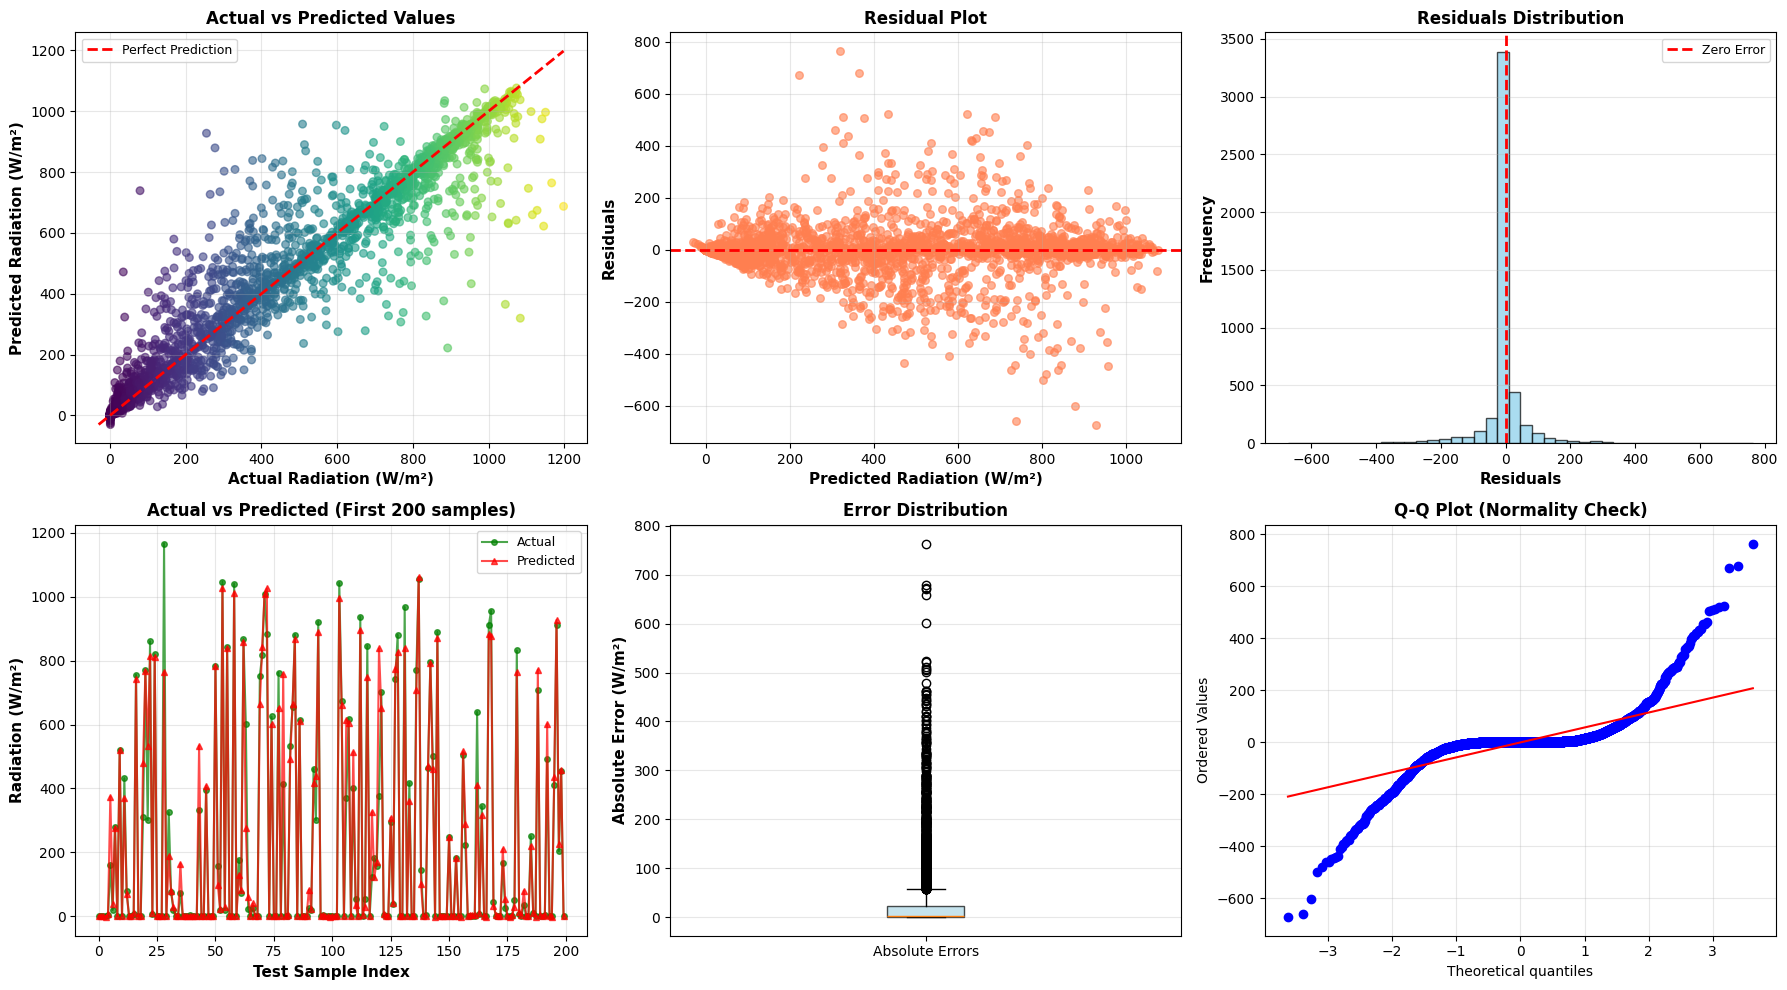

DETAILED PERFORMANCE METRICS:
   R² Score: 0.9463
   RMSE: 74.4298
   MAE: 2.2656
   Max Error: 763.9353
   Min Error: 0.0016
   MAPE: 100.00%
   Mean Residual: -1.0349
   Std Dev of Residuals: 74.4226
   Cross-Validation R² (Mean): 0.9419
   Cross-Validation R² (Std): 0.0038


In [44]:
# Best Model Deep Dive: Detailed Analysis and Hyperparameter Tuning
print("" + "="*100)
print("BEST MODEL DEEP DIVE ANALYSIS")
print("="*100)

# Get the best model from all final results by RMSE and MAE
best_model_final = min(all_final_results, key=lambda x: (x['RMSE'], x['MAE']))
best_model_name_final = best_model_final['Model']

print(f"Analyzing: {best_model_name_final}")
print(f"R² Score: {best_model_final['R² Score']:.4f} | RMSE: {best_model_final['RMSE']:.4f} | MAE: {best_model_final['MAE']:.4f}")

# Compute predictions for the best model
best_pred = best_deployed_model.predict(x_test_clean)

# Create detailed visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Actual vs Predicted
ax1 = axes[0, 0]
ax1.scatter(y_test, best_pred, alpha=0.6, s=30, c=y_test, cmap='viridis')
min_val = min(y_test.min(), best_pred.min())
max_val = max(y_test.max(), best_pred.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Radiation (W/m²)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Predicted Radiation (W/m²)', fontsize=11, fontweight='bold')
ax1.set_title('Actual vs Predicted Values', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# 2. Residuals
ax2 = axes[0, 1]
residuals = y_test.values - best_pred if hasattr(y_test, 'values') else y_test - best_pred
ax2.scatter(best_pred, residuals, alpha=0.6, s=30, c='coral')
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Predicted Radiation (W/m²)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Residuals', fontsize=11, fontweight='bold')
ax2.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)

# 3. Residuals Distribution
ax3 = axes[0, 2]
ax3.hist(residuals, bins=40, color='skyblue', edgecolor='black', alpha=0.7)
ax3.axvline(x=0, color='r', linestyle='--', lw=2, label='Zero Error')
ax3.set_xlabel('Residuals', fontsize=11, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax3.set_title('Residuals Distribution', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3, axis='y')

# 4. Time series of predictions
ax4 = axes[1, 0]
test_indices = range(len(y_test))
ax4.plot(test_indices[:200], y_test.values[:200] if hasattr(y_test, 'values') else y_test[:200], 
         'go-', label='Actual', alpha=0.7, linewidth=1.5, markersize=4)
ax4.plot(test_indices[:200], best_pred[:200], 'r^-', label='Predicted', alpha=0.7, linewidth=1.5, markersize=4)
ax4.set_xlabel('Test Sample Index', fontsize=11, fontweight='bold')
ax4.set_ylabel('Radiation (W/m²)', fontsize=11, fontweight='bold')
ax4.set_title('Actual vs Predicted (First 200 samples)', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)

# 5. Error distribution
ax5 = axes[1, 1]
errors = np.abs(residuals)
ax5.boxplot([errors], labels=['Absolute Errors'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7))
ax5.set_ylabel('Absolute Error (W/m²)', fontsize=11, fontweight='bold')
ax5.set_title('Error Distribution', fontsize=12, fontweight='bold')
ax5.grid(alpha=0.3, axis='y')

# 6. Q-Q plot for normality check
ax6 = axes[1, 2]
from scipy import stats as sp_stats
sp_stats.probplot(residuals, dist='norm', plot=ax6)
ax6.set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
ax6.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate additional metrics
mape = np.mean(np.abs((y_test.values if hasattr(y_test, 'values') else y_test - best_pred) / 
                      (y_test.values if hasattr(y_test, 'values') else y_test))) * 100 if all(y_test != 0) else np.nan
max_error = np.max(np.abs(residuals))
min_error = np.min(np.abs(residuals))

print(f"DETAILED PERFORMANCE METRICS:")
print(f"   R² Score: {best_model_final['R² Score']:.4f}")
print(f"   RMSE: {best_model_final['RMSE']:.4f}")
print(f"   MAE: {best_model_final['MAE']:.4f}")
print(f"   Max Error: {max_error:.4f}")
print(f"   Min Error: {min_error:.4f}")
if not np.isnan(mape):
    print(f"   MAPE: {mape:.2f}%")
print(f"   Mean Residual: {np.mean(residuals):.4f}")
print(f"   Std Dev of Residuals: {np.std(residuals):.4f}")
print(f"   Cross-Validation R² (Mean): {best_model_final['CV Mean R²']:.4f}")
print(f"   Cross-Validation R² (Std): {best_model_final['CV Std']:.4f}")

print("" + "="*100)

In [42]:
import pickle

# Use the best deployed model and scaler
trained_model = best_deployed_model
trained_scaler = scaler

# Save model
with open("model.pkl", "wb") as f:
    pickle.dump(trained_model, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(trained_scaler, f)

print("✅ model.pkl and scaler.pkl saved successfully for Streamlit")

✅ model.pkl and scaler.pkl saved successfully for Streamlit
